In [1]:
import geopandas as gpd
import pandas as pd
import ee
import os
import numpy as np
from pathlib import Path
from shapely.geometry import mapping
import geemap
from datetime import datetime

In [2]:
try:
    ee.Initialize(project='ee-biswajit001')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-biswajit001')

In [3]:
from eedata import GEETimeSeriesExtractor
from processors import TimeSeriesProcessor
from visualizer import TimeSeriesPlotter

In [4]:
cwd = Path.cwd()
farm_file_path = Path.joinpath(cwd, r'example_data\input\farm1.gpkg')
gdf = gpd.read_file(farm_file_path)

In [5]:
gdf.head()

,Shape_Area,AREA,geometry
0,0.0,16.117602,"POLYGON ((35.38742 -11.44702, 35.38624 -11.445..."


In [6]:
my_farm_geometry = geemap.gdf_to_ee(gdf).geometry()

In [7]:
# 1. Initialize the Extractor
extractor = GEETimeSeriesExtractor()

# 2. Fetch data: We want standard NDVI, but also a custom Soil Moisture proxy
raw_df = extractor.extract(
    aoi=my_farm_geometry,
    start_date='2025-06-01',
    # end_date='2026-04-01',
    end_date=datetime.now().strftime('%Y-%m-%d'), # Dynamic end date
    indices=['NDVI', 'NDTI'], 
    # custom_formulas={'CUSTOM_RATIO': 'b("B3") / b("B12")'}, # Dynamic!
    apply_mask=True # Toggle cloud masking
)

# 3. Process the data: Let's aggregate by Fortnight (2 Weeks)
processor = TimeSeriesProcessor(raw_df)
processed_df = processor.aggregate(frequency='2W').df

# (Optional: You could call processor.smooth_series('NDVI') here to get your arrays for peaks/dips)

# 4. Plot the data: Let's use Plotly for an interactive dashboard
plotter = TimeSeriesPlotter(processed_df)
plotter.plot_interactive(columns_to_plot=['NDVI', 'NDTI', 'CUSTOM_RATIO'], title="Farm 402 - Fortnightly Dynamics")

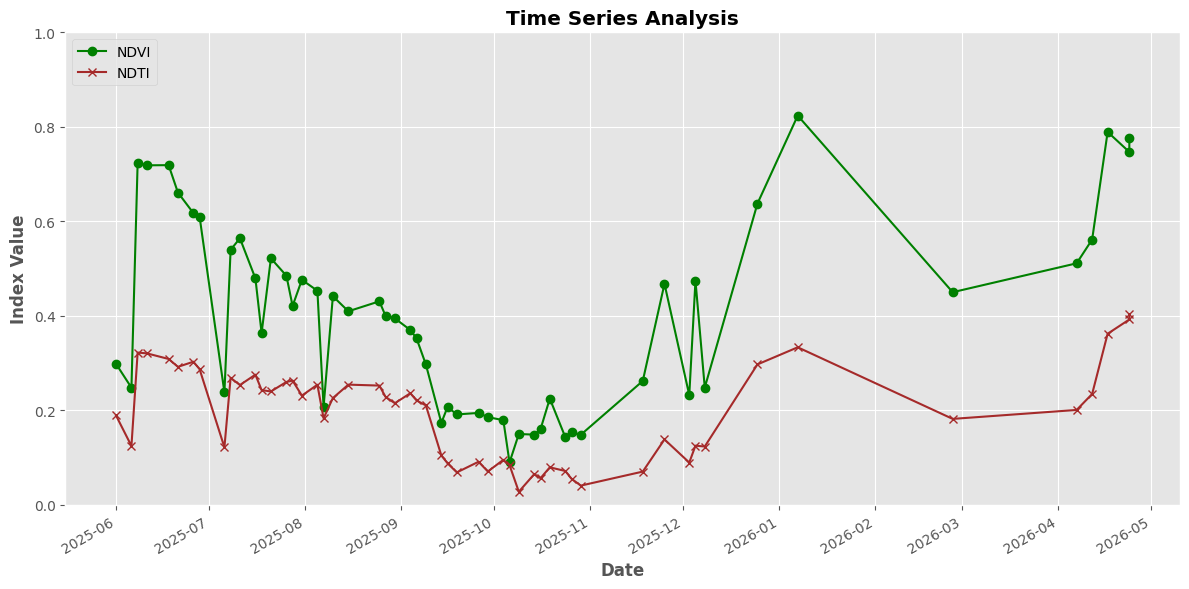

In [8]:
TimeSeriesPlotter(raw_df).plot_static(columns_to_plot=['NDVI', 'NDTI'], ylim=(0,1), style_dict={'NDVI': {'color': 'green', 'marker': 'o'}, 'NDTI': {'color': 'brown', 'marker': 'x'}}, save_file_path=r'example_data\output\farm1_time_series.png')

In [9]:
date, smooth_ndvi = processor.smooth_series('NDVI')
smooth_df = pd.DataFrame({'date': date, 'smooth_ndvi': smooth_ndvi})
TimeSeriesPlotter(smooth_df).plot_interactive(columns_to_plot=['smooth_ndvi'], title="Smoothed NDVI")

In [14]:
# Define Plotly-specific styling for the traces
plotly_styles = {
    'NDVI': {
        'line_color': 'green', 
        'mode': 'lines+markers', 
        'line_width': 3
    },
    'NDTI': {
        'line_color': 'orange', 
        'mode': 'lines', 
        'line_dash': 'dash' # Makes it a dashed line
    }
}

# Generate the interactive plot
plotter.plot_interactive(
    columns_to_plot=['NDVI', 'NDTI'],
    title="Farm 402 - Interactive Dynamics",
    style_dict=plotly_styles,
    
    # Everything below here is captured by **layout_kwargs and sent to update_layout()
    height=600,
    width=800,
    # xaxis_range=['2025-10-01', '2026-04-01'],
    yaxis_range=[0, 1],
    yaxis_title="Vegetation Indices",
    showlegend=True,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01) # Puts legend inside the plot
)